In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import financial_test as FCA
import pyRMT as rmt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
X_train_3D, X_test_3D = FCA.load_stock_data_rolling(len_rolling=300)
print(X_train_3D.shape)
print(X_test_3D.shape)

(9, 400, 800)
(9, 400, 60)


Distribuzione dei pesi Rie 

[1] Portafoglio casuale: 1.0
[1] Variance of the portfolio: 1089594.7652924692
[2] Portafoglio casuale: 1.0
[2] Variance of the portfolio: 89064.1311425893
[3] Portafoglio casuale: 1.0
[3] Variance of the portfolio: 12602.675316449433
[4] Portafoglio casuale: 1.0
[4] Variance of the portfolio: 39087.694803942155
[5] Portafoglio casuale: 1.0
[5] Variance of the portfolio: 48963.49455447175
[6] Portafoglio casuale: 1.0
[6] Variance of the portfolio: 378830.88411307166


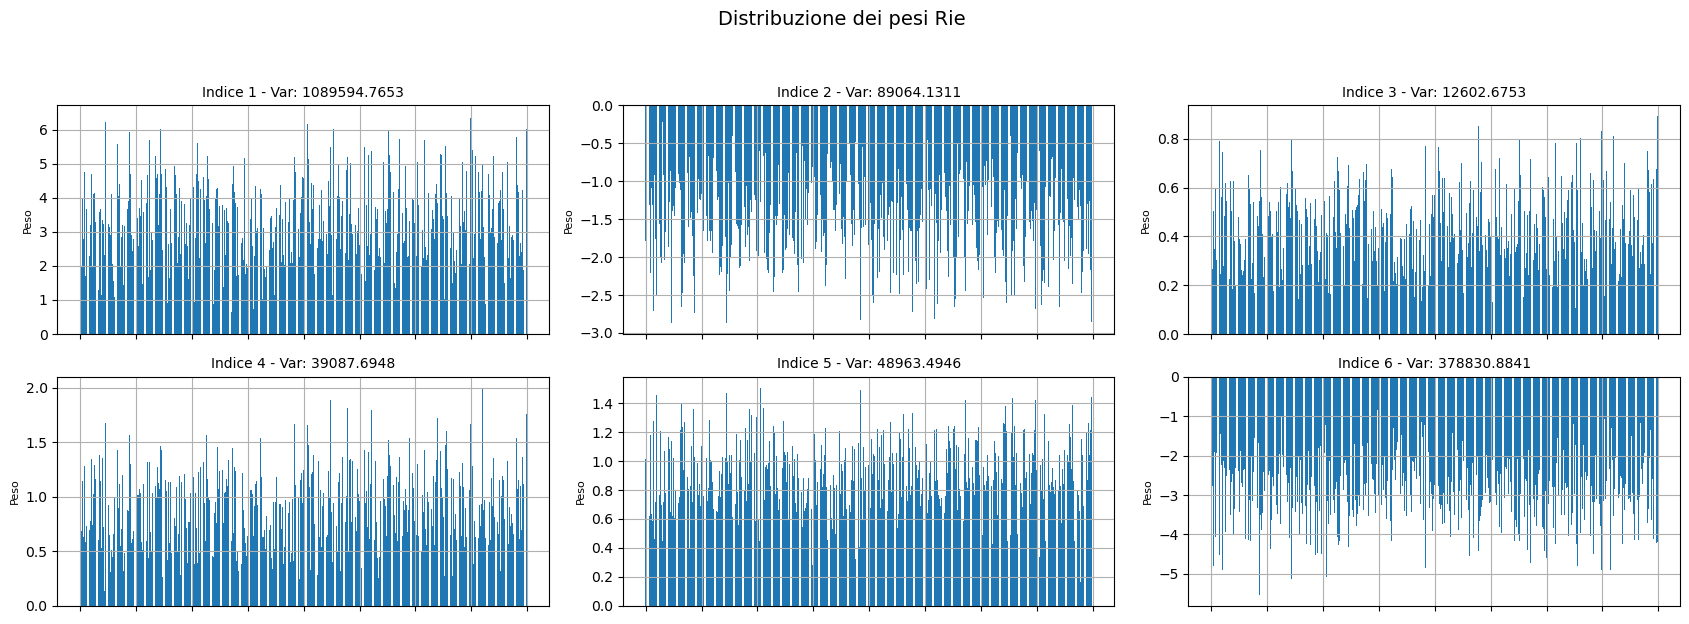

In [21]:
np.random.seed(42)
indici = range(1, 7)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)
axs = axs.flatten()  # Flatten per iterare facilmente
Sigma_method = 'Rie '

print(f"Distribuzione dei pesi {Sigma_method}\n")

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    X_test_std, _, _ = FCA.standardize_returns(X_test_3D[i])
    N, T = matrice.shape

    method = 'minimum_variance'
    g = FCA.random_long_short_portfolio_vector(matrice)
    print(f'[{i}] Portafoglio casuale: {np.linalg.norm(g):.1f}')
    #g = np.ones(N)
    sigma_train = rmt.optimalShrinkage(matrice, return_covariance=True, method="rie")

    w = FCA.optimal_weights(sigma_train, g)
    sigma_test = np.cov(X_test_std)
    var = FCA.variance_portfolio(sigma_test, w, Sigma_method, method)
    print(f'[{i}] Variance of the portfolio:', var)

    axs[idx].bar(range(N), w)
    axs[idx].set_title(f'Indice {i} - Var: {var:.4f}', fontsize=10)
    axs[idx].set_ylabel("Peso", fontsize=8)
    axs[idx].grid(True)

# Rimuovi subplot vuoti se ci sono
for j in range(len(indici), len(axs)):
    fig.delaxes(axs[j])

fig.suptitle(f"Distribuzione dei pesi {Sigma_method}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

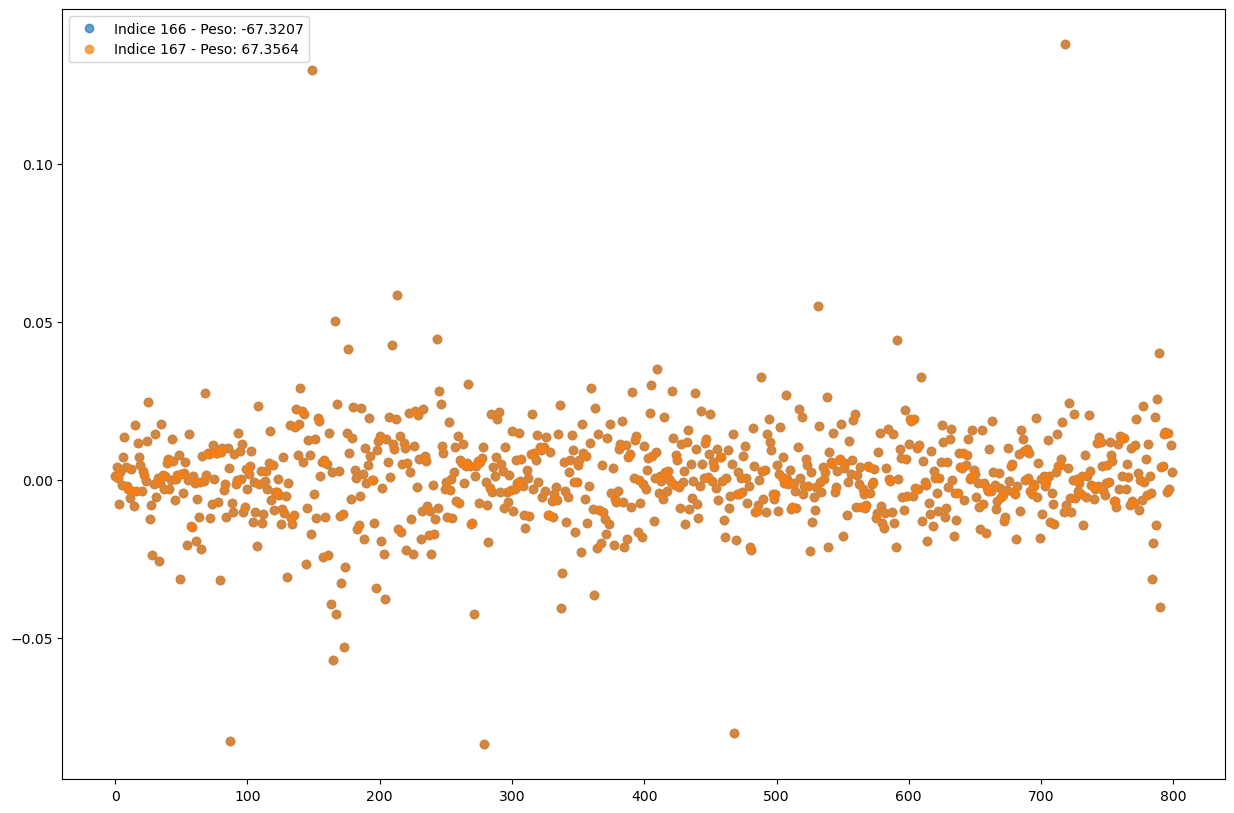

In [81]:
i = 19
matrice = X_train_3D[i]
X_test_std, _, _ = FCA.standardize_returns(X_test_3D[i])
N, T = matrice.shape

method = 'minimum_variance'
g = np.ones(N)
sigma_train = np.cov(matrice)

w = FCA.optimal_weights(sigma_train, g)
indice_minimo = np.argmin(w)
indice_massimo = np.argmax(w)

time = np.arange(T)
plt.figure(figsize=(15, 10))
plt.plot(time, matrice[indice_minimo], "o", alpha=0.7, label=f'Indice {indice_minimo} - Peso: {w[indice_minimo]:.4f}')
plt.plot(time, matrice[indice_massimo], "o", alpha=0.7, label=f'Indice {indice_massimo} - Peso: {w[indice_massimo]:.4f}' )
#plt.plot(time, matrice[indice_minimo-1], "o", alpha=0.3,  label=f'Indice {indice_minimo - 1} - Peso: {w[indice_minimo -1]:.4f}')
#plt.plot(time, matrice[indice_minimo+1], "o",alpha=0.3,  label=f'Indice {indice_minimo + 1} - Peso: {w[indice_minimo +1]:.4f}')
plt.legend()
plt.show()




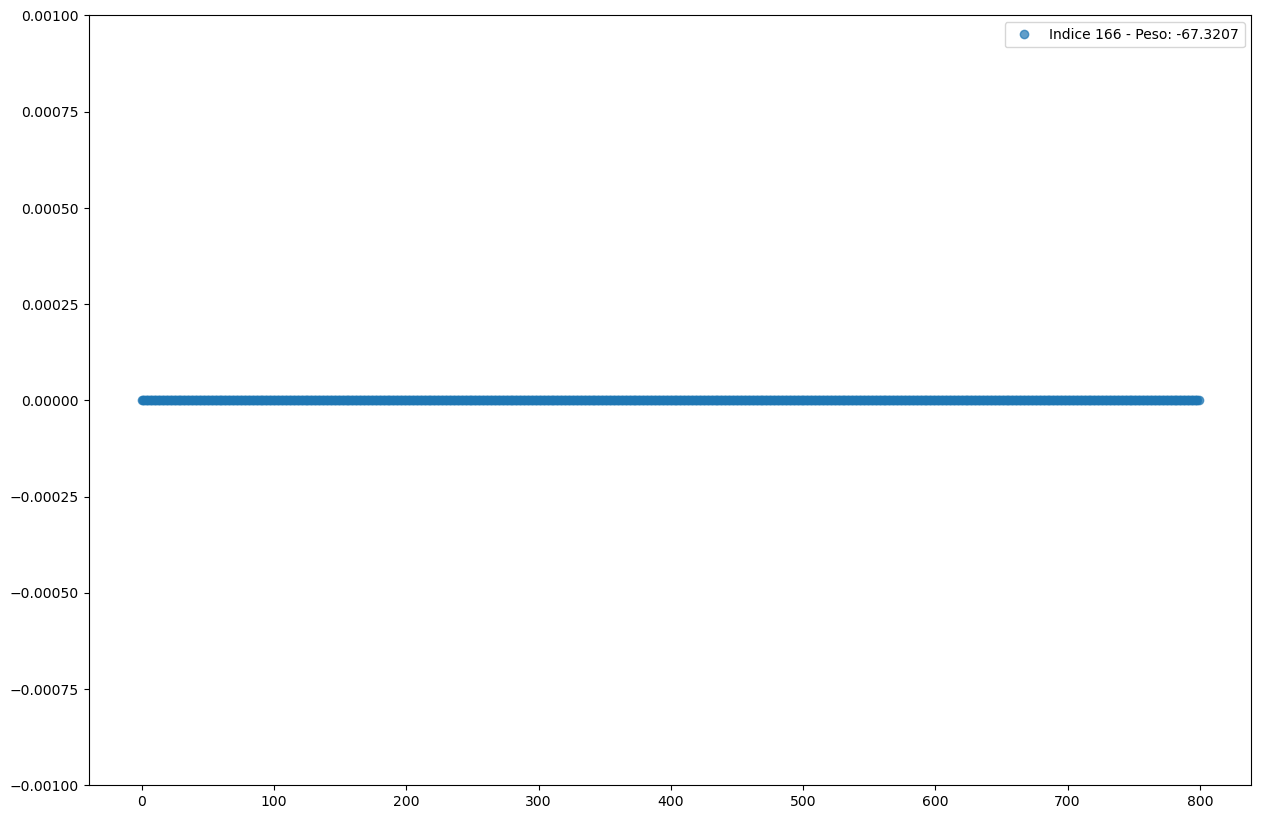

In [82]:
time = np.arange(T)
plt.figure(figsize=(15, 10))
plt.plot(time, matrice[indice_minimo] - matrice[indice_massimo], "o", alpha=0.7, label=f'Indice {indice_minimo} - Peso: {w[indice_minimo]:.4f}')
plt.ylim([-1e-3, 1e-3])
#plt.plot(time, matrice[indice_massimo], "o", alpha=0.7, label=f'Indice {indice_massimo} - Peso: {w[indice_massimo]:.4f}' )
#plt.plot(time, matrice[indice_minimo-1], "o", alpha=0.3,  label=f'Indice {indice_minimo - 1} - Peso: {w[indice_minimo -1]:.4f}')
#plt.plot(time, matrice[indice_minimo+1], "o",alpha=0.3,  label=f'Indice {indice_minimo + 1} - Peso: {w[indice_minimo +1]:.4f}')
plt.legend()
plt.show()

In [76]:
# Supponiamo che 'matrice' sia un array 2D
duplicati = np.unique(matrice, axis=0, return_counts=True)

# Estrai righe e conteggi
righe_uniche, conteggi = duplicati

# Trova le righe duplicate (conteggi > 1)
righe_duplicati = righe_uniche[conteggi > 1]

if len(righe_duplicati) > 0:
    print("Ci sono righe duplicate:")
    print(righe_duplicati)
else:
    print("Non ci sono righe duplicate.")

Non ci sono righe duplicate.


Distribuzione dei pesi Kendall Covariance

[15] Variance of the portfolio: 3.3818679838631387e+26
[16] Variance of the portfolio: 1.6579322775927414e+27
[17] Variance of the portfolio: 1.3374229475882145e+27
[18] Variance of the portfolio: 1.8371707169032438e+18
[19] Variance of the portfolio: 0.2502453749572267
[20] Variance of the portfolio: 0.08559866499264047
[21] Variance of the portfolio: 0.13852402633310523
[22] Variance of the portfolio: 0.12977272522524091
[23] Variance of the portfolio: 0.1297725936845725


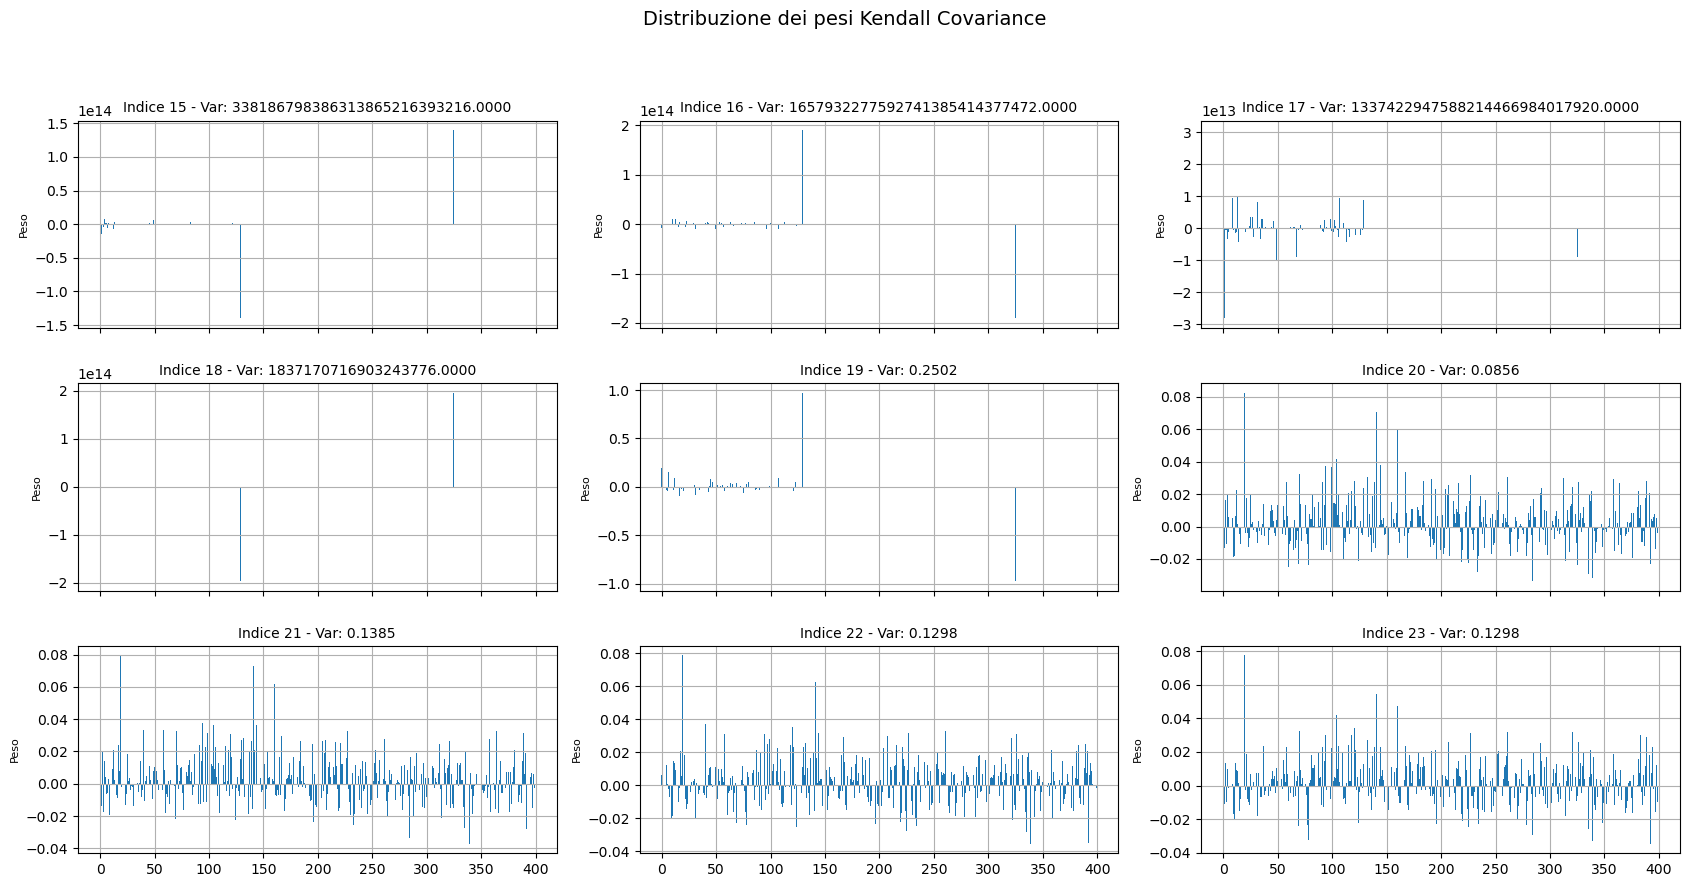

In [30]:
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)
axs = axs.flatten()  # Flatten per iterare facilmente
Sigma_method = 'Kendall Covariance'

print(f"Distribuzione dei pesi {Sigma_method}\n")

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    X_test_std, _, _ = FCA.standardize_returns(X_test_3D[i])
    N, T = matrice.shape

    method = 'minimum_variance'
    g = np.ones(N)
    sigma_train = FCA.kendall_tau_matrix_parallel(matrice)
    w = FCA.optimal_weights(sigma_train, g)
    sigma_test = np.cov(X_test_std)
    var = FCA.variance_portfolio(sigma_test, w, method)
    print(f'[{i}] Variance of the portfolio:', var)

    axs[idx].bar(range(N), w)
    axs[idx].set_title(f'Indice {i} - Var: {var:.4f}', fontsize=10)
    axs[idx].set_ylabel("Peso", fontsize=8)
    axs[idx].grid(True)

# Rimuovi subplot vuoti se ci sono
for j in range(len(indici), len(axs)):
    fig.delaxes(axs[j])

fig.suptitle(f"Distribuzione dei pesi {Sigma_method}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

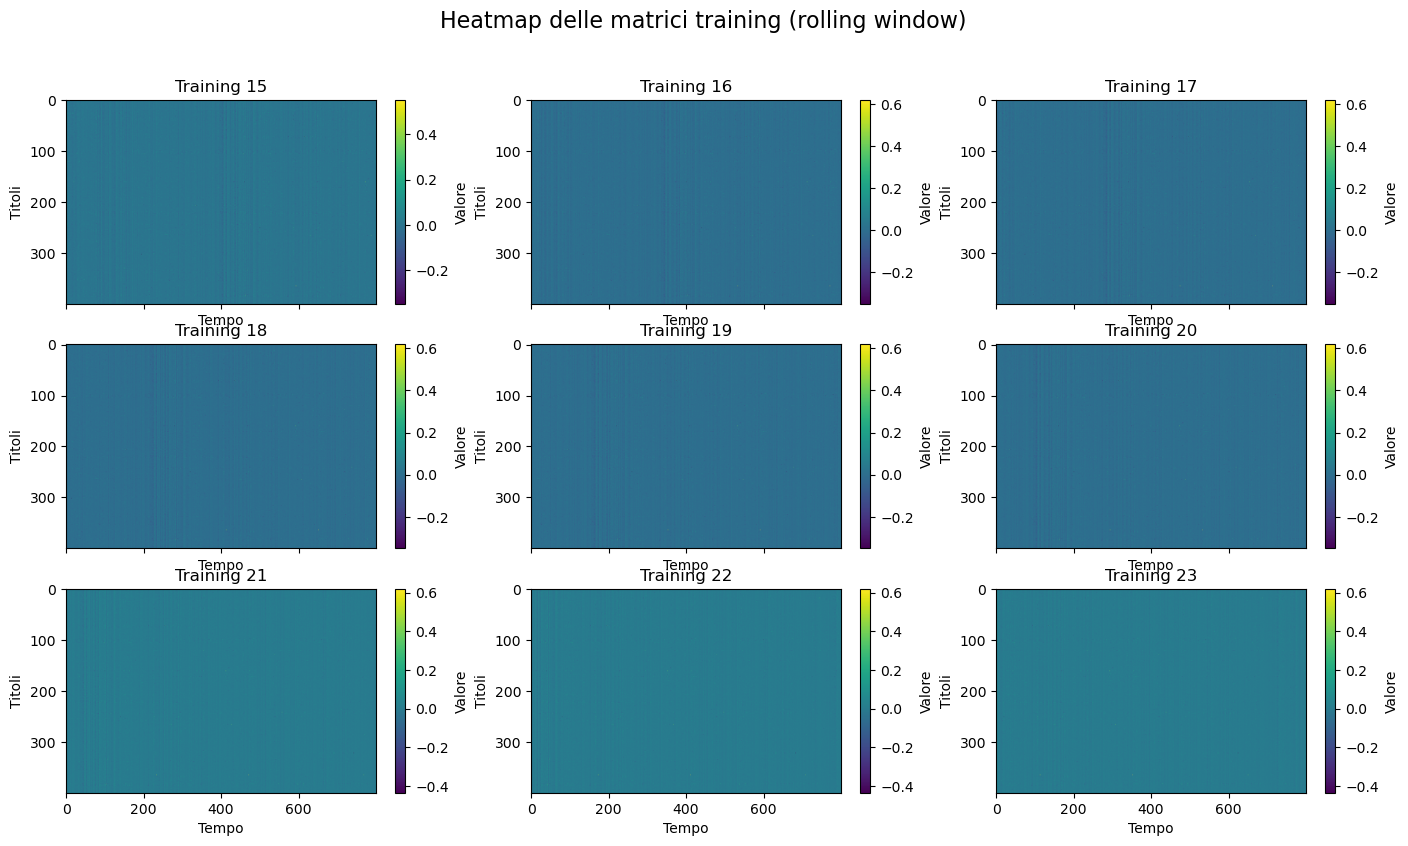

In [ ]:
import matplotlib.pyplot as plt

# Indici da plottare
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    cbar.set_label('Valore')

    axs[idx].set_title(f"Training {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Tempo")
    
plt.suptitle("Heatmap delle matrici training (rolling window)", fontsize=16)
plt.show()

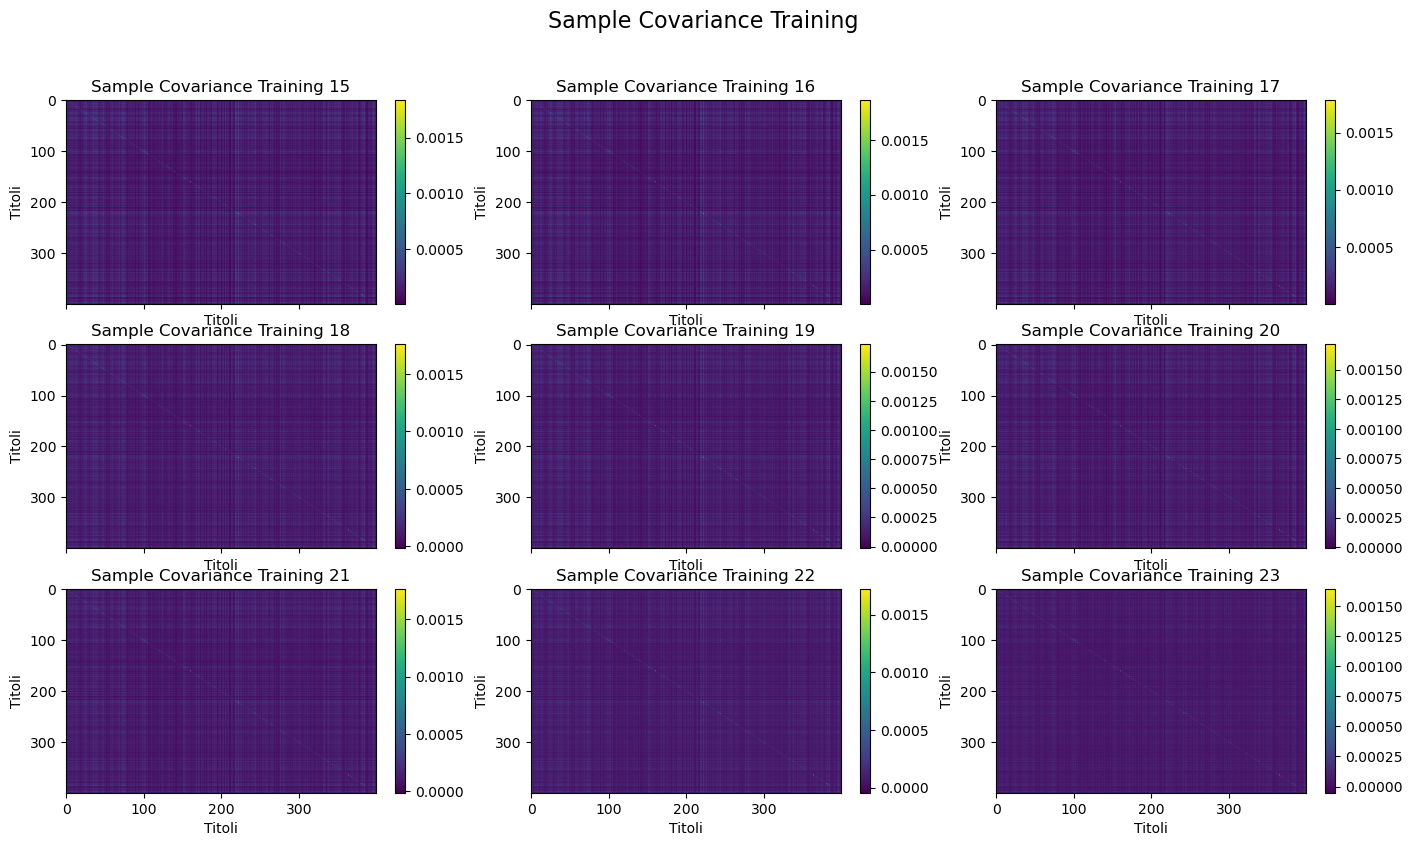

In [18]:

indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    matrice = np.cov(matrice)
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    #cbar.set_label('Valore')

    axs[idx].set_title(f"Sample Covariance Training {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Titoli")
    
plt.suptitle("Sample Covariance Training", fontsize=16)
plt.show()

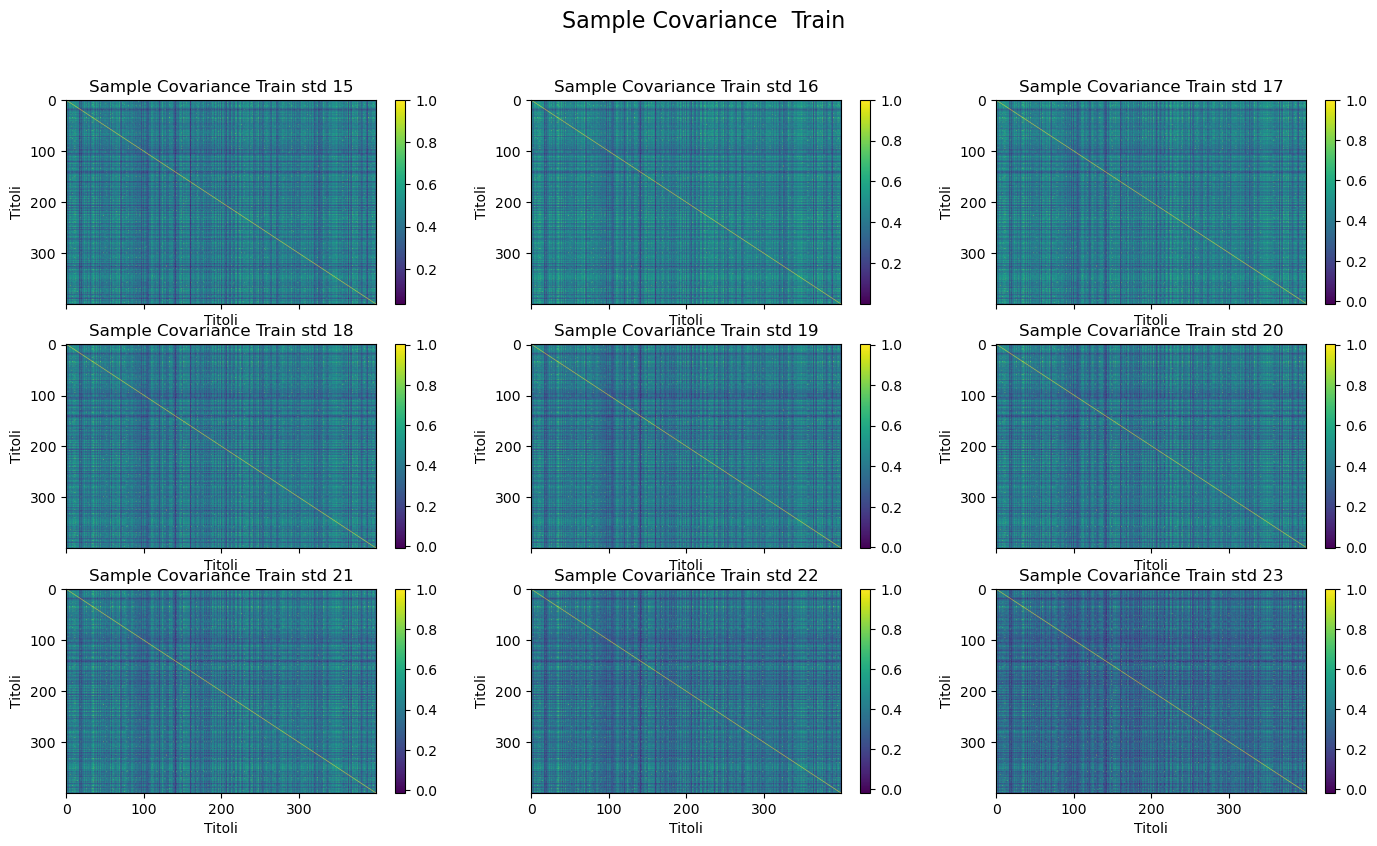

In [23]:
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    matrice, _, _ = FCA.standardize_returns(matrice)
    matrice = np.cov(matrice)
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    #cbar.set_label('Valore')

    axs[idx].set_title(f"Sample Covariance Train std {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Titoli")
    
plt.suptitle("Sample Covariance  Train", fontsize=16)
plt.show()

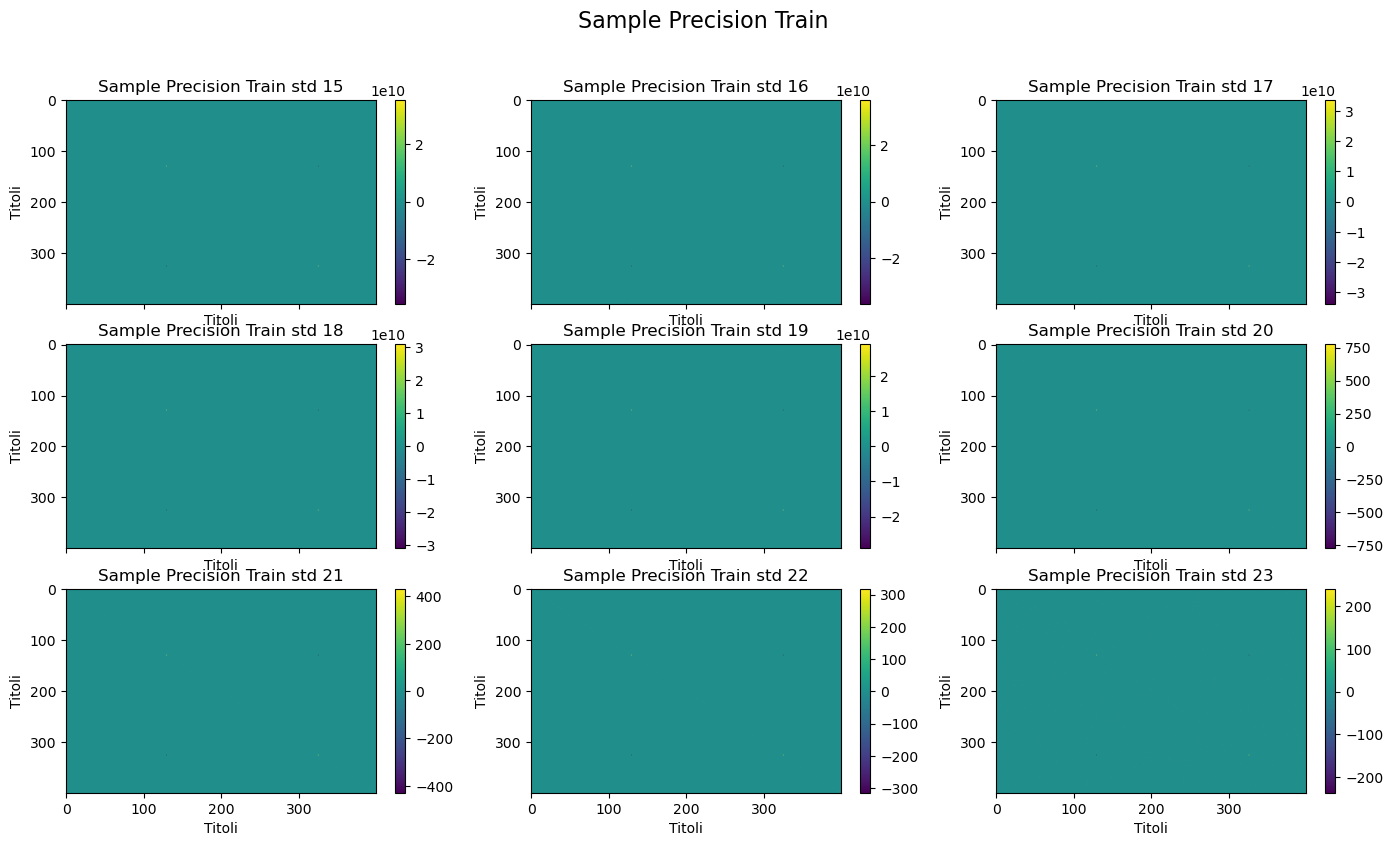

In [24]:
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_train_3D[i]
    matrice, _, _ = FCA.standardize_returns(matrice)
    matrice = np.cov(matrice)
    matrice = np.linalg.inv(matrice)
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    #cbar.set_label('Valore')

    axs[idx].set_title(f"Sample Precision Train std {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Titoli")
    
plt.suptitle("Sample Precision Train", fontsize=16)
plt.show()

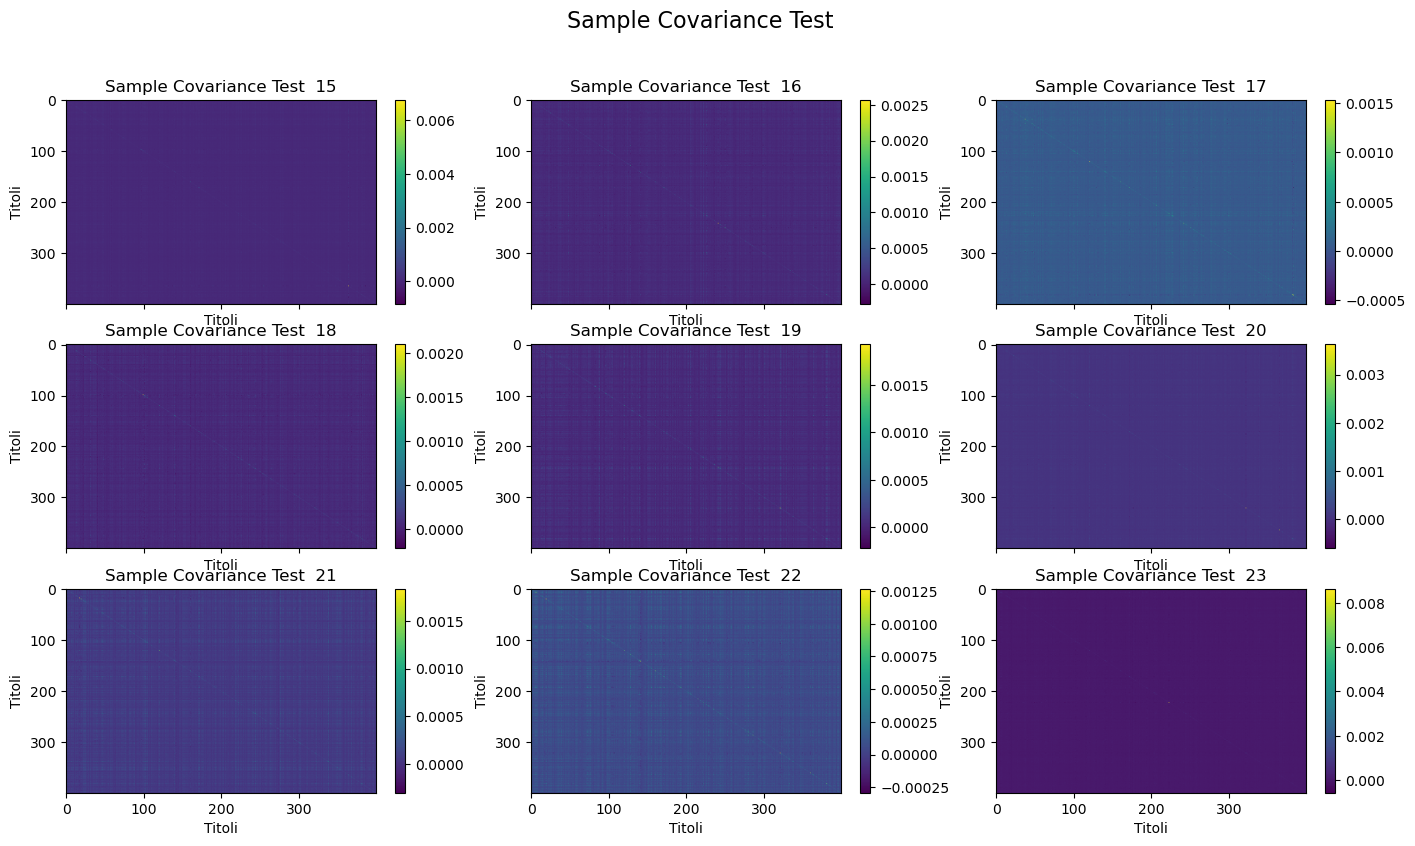

In [22]:
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_test_3D[i]
    #matrice, _, _ = FCA.standardize_returns(matrice)
    matrice = np.cov(matrice)
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    #cbar.set_label('Valore')

    axs[idx].set_title(f"Sample Covariance Test  {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Titoli")
    
plt.suptitle("Sample Covariance Test ", fontsize=16)
plt.show()

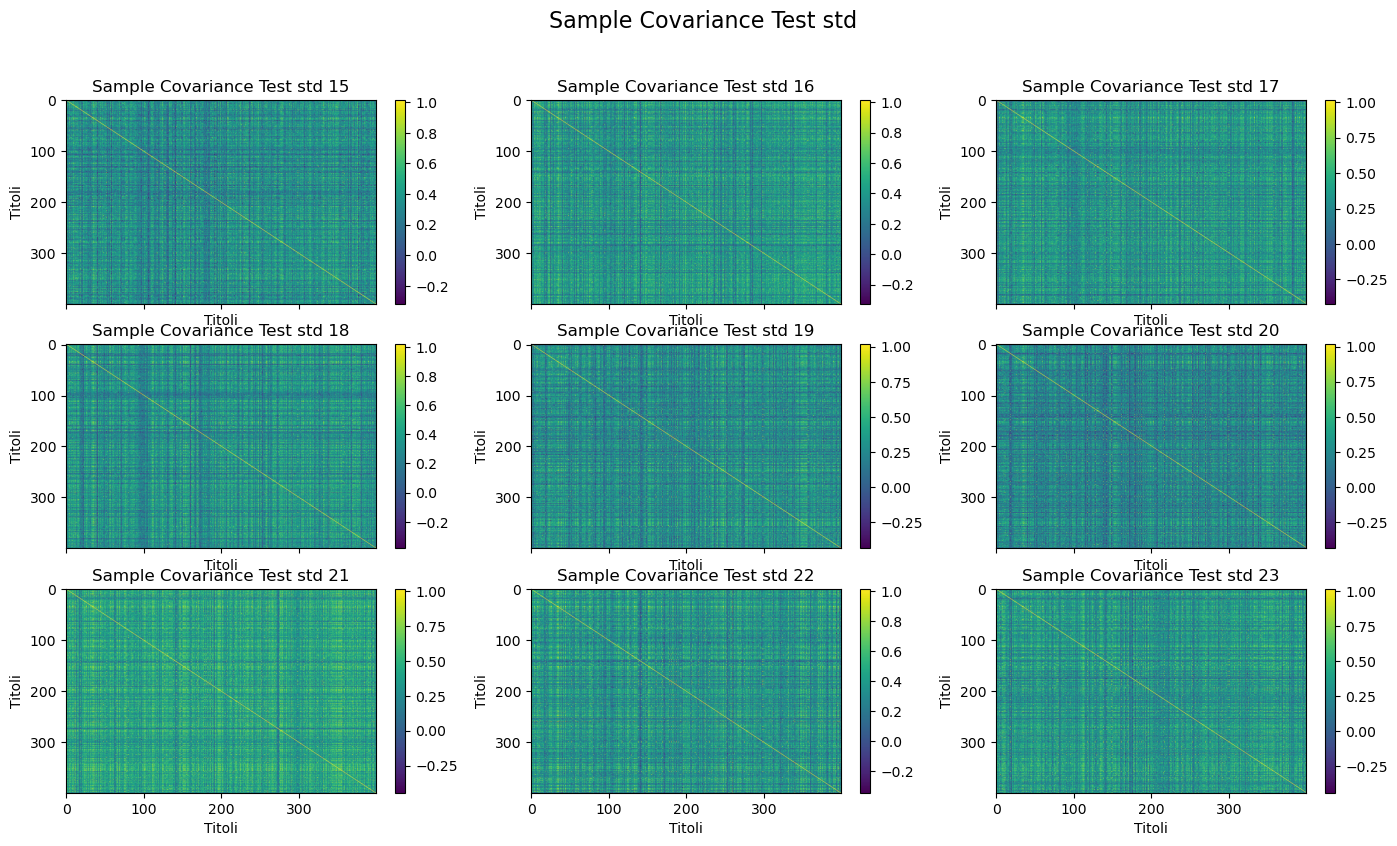

In [19]:
indici = range(15, 24)
num_plot = len(indici)
rows, cols = 3, 3  # Griglia 2x3

fig, axs = plt.subplots(rows, cols, figsize=(17, 9), sharex=True)

axs = axs.flatten()

for idx, i in enumerate(indici):
    matrice = X_test_3D[i]
    matrice, _, _ = FCA.standardize_returns(matrice)
    matrice = np.cov(matrice)
    im = axs[idx].imshow(matrice, aspect='auto', cmap='viridis')
    
    # Aggiungi colorbar per ogni subplot
    cbar = fig.colorbar(im, ax=axs[idx])
    #cbar.set_label('Valore')

    axs[idx].set_title(f"Sample Covariance Test std {i}")
    axs[idx].set_ylabel("Titoli")
    axs[idx].set_xlabel("Titoli")
    
plt.suptitle("Sample Covariance Test std", fontsize=16)
plt.show()